多层感知机（MLP）说白了就是加入隐藏层让网络不在仅仅能学线性的，也能学习非线性关系

## 常用的隐藏层函数

In [1]:
%matplotlib inline
import torch
import matplotlib.pyplot as plt
def plot_xy(x, y, xlabel, ylabel, figsize=(5, 2.5)):
    plt.figure(figsize=figsize)
    plt.plot(x.detach().numpy(), y.detach().numpy())
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True)
    plt.show()

### ReLU
$ ReLU(x)=max(0,x) $

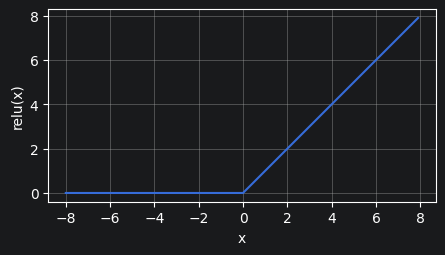

In [2]:
x = torch.arange(-8.0, 8.0, 0.1, requires_grad=True)
y = torch.relu(x)
plot_xy(x, y, 'x', 'relu(x)')

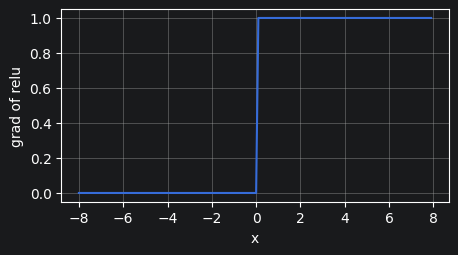

In [3]:
y.backward(torch.ones_like(x))
plot_xy(x, x.grad, 'x', 'grad of relu')

### sigmoid

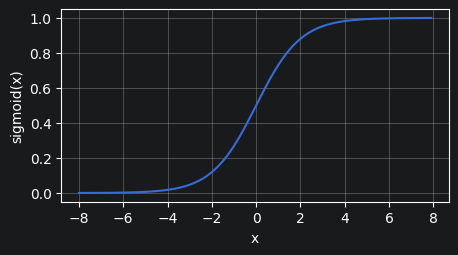

In [4]:
y = torch.sigmoid(x)
plot_xy(x, y, 'x', 'sigmoid(x)')

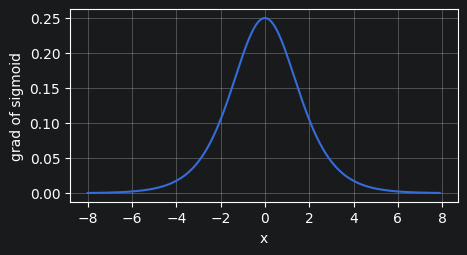

In [5]:
x.grad.zero_()
y.backward(torch.ones_like(x))
plot_xy(x, x.grad, 'x', 'grad of sigmoid')

### 双曲正切函数

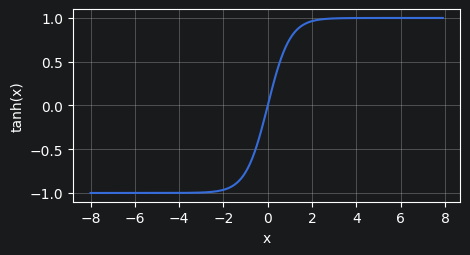

In [6]:
y = torch.tanh(x)
plot_xy(x, y, 'x', 'tanh(x)')

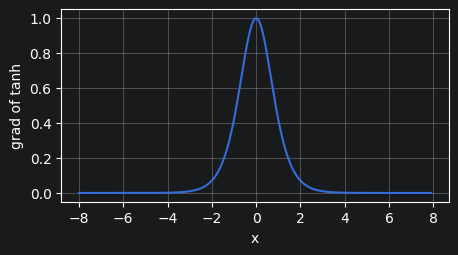

In [7]:
x.grad.zero_()
y.backward(torch.ones_like(x))
plot_xy(x, x.grad, 'x', 'grad of tanh')

# 从0开始实现

## 依旧以图像感知数据集为例

In [8]:
%matplotlib inline
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
batch_size = 256
def load_data_fashion_mnist(batch_size, resize=None):
    trans = []
    if resize:
        trans.append(transforms.Resize(resize))
    trans.append(transforms.ToTensor())
    transform = transforms.Compose(trans)
    train_dataset = datasets.FashionMNIST(
        root="./data",
        train=True,
        transform=transform,
        download=True
    )
    test_dataset = datasets.FashionMNIST(
        root="./data",
        train=False,
        transform=transform,
        download=True
    )
    train_iter = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0
    )
    test_iter = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0
    )
    return train_iter, test_iter
train_iter, test_iter = load_data_fashion_mnist(batch_size)

## 初始化参数

In [9]:
num_inputs, num_outputs, num_hiddens = 784, 10, 256
W1 = nn.Parameter(torch.randn(num_inputs, num_hiddens) * 0.01)
b1 = nn.Parameter(torch.zeros(num_hiddens))
W2 = nn.Parameter(torch.randn(num_hiddens, num_outputs) * 0.01)
b2 = nn.Parameter(torch.zeros(num_outputs))
params = [W1, b1, W2, b2]

In [10]:
def relu(X):
    a = torch.zeros_like(X)
    return torch.max(X, a)

In [14]:
def net(X):
    X = X.reshape((-1, num_inputs))
    H = relu(X @ W1 + b1)  # @ 表示矩阵乘法
    return H @ W2 + b2

In [15]:
loss = nn.CrossEntropyLoss(reduction='none')

## 和前面差不多的老生常谈训练

In [16]:
def accuracy(y_hat, y):
    """计算预测正确的数量"""
    if len(y_hat.shape) > 1 and y_hat.shape[1] > 1:
        y_hat = y_hat.argmax(axis=1)
    cmp = y_hat.type(y.dtype) == y
    return float(cmp.sum())
def evaluate_accuracy(net, data_iter):
    """计算模型在数据集上的准确率"""
    if isinstance(net, torch.nn.Module):
        net.eval()
    metric_correct = 0.0
    metric_total = 0
    with torch.no_grad():
        for X, y in data_iter:
            metric_correct += accuracy(net(X), y)
            metric_total += y.numel()
    return metric_correct / metric_total
def train_epoch_ch3(net, train_iter, loss, updater):
    """训练一个 epoch"""
    if isinstance(net, torch.nn.Module):
        net.train()
    total_loss = 0.0
    total_correct = 0.0
    total_num = 0
    for X, y in train_iter:
        y_hat = net(X)
        l = loss(y_hat, y)
        updater.zero_grad()
        l.mean().backward()
        updater.step()
        total_loss += float(l.sum())
        total_correct += accuracy(y_hat, y)
        total_num += y.numel()
    return total_loss / total_num, total_correct / total_num
def train_ch3(net, train_iter, test_iter, loss, num_epochs, updater):
    """替代 d2l.train_ch3"""
    for epoch in range(num_epochs):
        train_loss, train_acc = train_epoch_ch3(
            net,
            train_iter,
            loss,
            updater
        )
        test_acc = evaluate_accuracy(net, test_iter)
        print(
            f'epoch {epoch + 1}, '
            f'loss {train_loss:.4f}, '
            f'train acc {train_acc:.3f}, '
            f'test acc {test_acc:.3f}'
        )
num_epochs, lr = 10, 0.1
updater = torch.optim.SGD(params, lr=lr)
train_ch3(net, train_iter, test_iter, loss, num_epochs, updater)

C:\Users\hp\AppData\Local\Temp\ipykernel_32064\285175564.py:31: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  total_loss += float(l.sum())


epoch 1, loss 1.0457, train acc 0.646, test acc 0.761
epoch 2, loss 0.5954, train acc 0.792, test acc 0.795
epoch 3, loss 0.5190, train acc 0.818, test acc 0.774
epoch 4, loss 0.4782, train acc 0.833, test acc 0.820
epoch 5, loss 0.4542, train acc 0.840, test acc 0.817
epoch 6, loss 0.4366, train acc 0.847, test acc 0.833
epoch 7, loss 0.4222, train acc 0.850, test acc 0.844
epoch 8, loss 0.4081, train acc 0.856, test acc 0.843
epoch 9, loss 0.3969, train acc 0.861, test acc 0.825
epoch 10, loss 0.3846, train acc 0.865, test acc 0.845


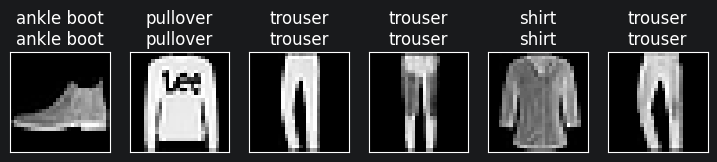

In [17]:
def get_fashion_mnist_labels(labels):
    text_labels = [
        't-shirt', 'trouser', 'pullover', 'dress', 'coat',
        'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot'
    ]
    return [text_labels[int(i)] for i in labels]
def show_images(imgs, num_rows, num_cols, titles=None, scale=1.5):
    figsize = (num_cols * scale, num_rows * scale)
    _, axes = plt.subplots(num_rows, num_cols, figsize=figsize)
    if num_rows * num_cols == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    for i, (ax, img) in enumerate(zip(axes, imgs)):
        if torch.is_tensor(img):
            img = img.detach().numpy()
        ax.imshow(img, cmap='gray')
        ax.axes.get_xaxis().set_visible(False)
        ax.axes.get_yaxis().set_visible(False)
        if titles:
            ax.set_title(titles[i])
    plt.show()
def predict_ch3(net, test_iter, n=6):
    for X, y in test_iter:
        break
    trues = get_fashion_mnist_labels(y[:n])
    preds = get_fashion_mnist_labels(net(X[:n]).argmax(axis=1))
    titles = [
        true + '\n' + pred
        for true, pred in zip(trues, preds)
    ]
    show_images(
        X[:n].reshape((n, 28, 28)),
        1,
        n,
        titles=titles
    )
predict_ch3(net, test_iter)